<a href="https://colab.research.google.com/github/shreyashahane1410-maker/ANNDL_Projects/blob/main/Shreya_Shahane(A_72)TA01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

         Date  SP500  Dividend  Earnings  Consumer Price Index  \
0  1871-01-01   4.44      0.26       0.4                 12.46   
1  1871-02-01   4.50      0.26       0.4                 12.84   
2  1871-03-01   4.61      0.26       0.4                 13.03   
3  1871-04-01   4.74      0.26       0.4                 12.56   
4  1871-05-01   4.86      0.26       0.4                 12.27   

   Long Interest Rate  Real Price  Real Dividend  Real Earnings  PE10  
0                5.32      109.05           6.39           9.82   0.0  
1                5.32      107.25           6.20           9.53   0.0  
2                5.33      108.27           6.11           9.39   0.0  
3                5.33      115.54           6.34           9.75   0.0  
4                5.33      121.22           6.48           9.98   0.0  


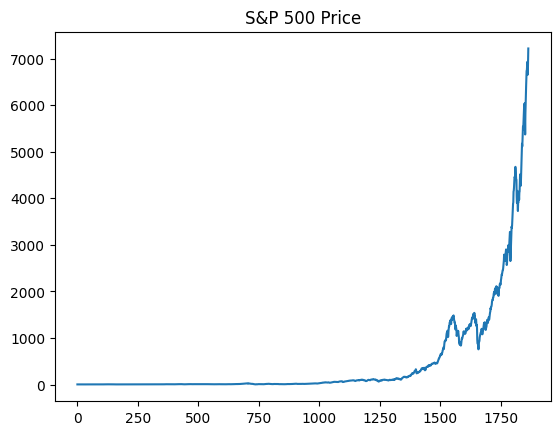

In [ ]:
# STEP 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# STEP 2: Load Dataset

url = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"
df = pd.read_csv(url)

print(df.head())


# STEP 3: Select One Company
# Convert date
df['date'] = pd.to_datetime(df['Date'])

# Sort
df = df.sort_values('date')

# Use SP500 price for prediction
data = df[['SP500']].values

# Plot
plt.plot(data)
plt.title("S&P 500 Price") # Updated title
plt.show()

In [ ]:

# STEP 4: Normalize

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# STEP 5: Create Sequences

X, y = [], []
time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:

# STEP 6: Split

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# STEP 7: Model

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# STEP 8: Train

model.fit(X_train, y_train, epochs=20, batch_size=32)

# STEP 9: Predict

pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))


Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 5.6961e-05
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 6.3394e-06
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 6.0731e-06
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 6.1307e-06
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 6.1733e-06
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 5.6706e-06
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.4556e-06
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.9488e-06
Epoch 9/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 6.5629e-06
Epoch 10/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 5.8187e-06
Epoch 11/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.2279e-06
Epoch 12/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.8065e-06
Epoch 13/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 4.6185e-06
Epoch 14/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 4.6641e-06
Epoch 15/20
46/

In [ ]:
# STEP 10: Evaluation

mae = mean_absolute_error(y_test_actual, pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, pred))
mape = np.mean(np.abs((y_test_actual - pred) / y_test_actual)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 189.3984913680173
RMSE: 264.7048789658248
MAPE: 8.67364997442024


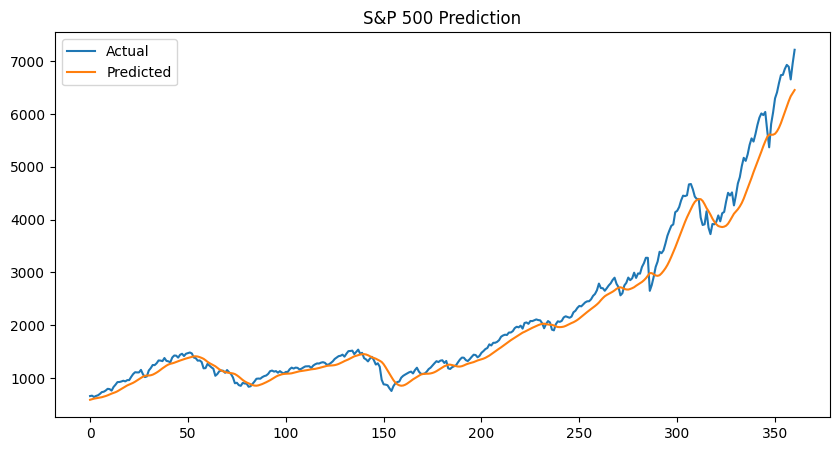

In [ ]:

# STEP 11: Graph

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("S&P 500 Prediction") # Updated title
plt.show()